In [ ]:
%%javascript
// Keep-alive: click connect every 60s / fallback logger
function clickConnect(){
  const btn = document.querySelector("colab-connect-button")
           || document.querySelector("colab-toolbar-button#connect")
           || document.querySelector("#connect");
  if(btn){
    btn.click();
    console.log("⏳ clicked connect");
  } else {
    console.log("⏳ keep-alive tick");
  }
}
setInterval(clickConnect, 1000 * 60);

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STEP 1 : LOAD DATASET FROM GOOGLE DRIVE
# ============================================================
# Use the raw dataset from the following link for segmentation, use only the Ringworm class folder (STEP 1 IN README):
# https://drive.google.com/drive/folders/1Yx9Q53DPpq9qDSJFPgDQ2xX2B-di9XjS?usp=sharing
#
# How to use:
# 1. Open the link above
# 2. Click "Add shortcut to Drive"
# 3. Make sure the folder is saved in:
#    /content/drive/MyDrive/segmentation
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required packages. If the Torch version in Collab changes, install it according to the environment.
!pip install -q segmentation-models-pytorch==0.3.3 albumentations opencv-python tqdm matplotlib
# albumentations installs numpy/pillow; segmentation-models-pytorch depends on efficientnet-pytorch sometimes but pip resolves it.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.4 MB/s eta 0:00:00


In [ ]:
import os, sys
DRIVE_DATASET_PATH = "/content/drive/MyDrive/segmentation"  # <<--- CHANGE this path according to the folder in Drive. Use ONLY the Ringworm class/folder.
IMAGES_DIR = os.path.join(DRIVE_DATASET_PATH, "image")
MASKS_DIR  = os.path.join(DRIVE_DATASET_PATH, "masks")

CHECKPOINT_PATH = os.path.join("/content/drive/MyDrive", "unet_vgg_checkpoint.pth")
BEST_MODEL_PATH = os.path.join("/content/drive/MyDrive", "unet_vgg_best.pth")
LOGS_PATH = os.path.join("/content/drive/MyDrive", "training_logs.npz")  # store loss/iou

print("Images dir:", IMAGES_DIR)
print("Masks dir :", MASKS_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Best model:", BEST_MODEL_PATH)

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Images dir: /content/drive/MyDrive/segmentasi/image
Masks dir : /content/drive/MyDrive/segmentasi/masks
Checkpoint: /content/drive/MyDrive/unet_vgg_checkpoint.pth
Best model: /content/drive/MyDrive/unet_vgg_best.pth
Device: cpu


In [ ]:
import os, cv2, numpy as np, torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

class RingwormDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transforms=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        # only files with typical image extensions
        imgs = [f for f in sorted(os.listdir(image_dir)) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        self.images = imgs
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        name = self.images[idx]
        img_path = os.path.join(self.image_dir, name)
        mask_path = os.path.join(self.mask_dir, os.path.splitext(name)[0] + ".png")

        img = cv2.imread(img_path)[:,:,::-1]  # BGR->RGB
        mask = cv2.imread(mask_path, 0)
        if mask is None:
            # fallback: empty mask
            mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        mask = (mask > 127).astype('uint8')

        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']

        # Return image tensor [C,H,W] and mask tensor [1,H,W]
        return img, mask.unsqueeze(0).float()


In [ ]:
from torch.utils.data import DataLoader, random_split

IMG_SIZE = 256
BATCH_SIZE = 4
NUM_WORKERS = 2

train_tf = A.Compose([
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),   
        scale=(0.6, 1.0),
        ratio=(0.75, 1.33),
        p=1.0
    ),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

dataset = RingwormDataset(IMAGES_DIR, MASKS_DIR, transforms=train_tf)
n_total = len(dataset)
val_size = max(1, int(0.2 * n_total))
train_size = n_total - val_size

train_set, val_set = random_split(dataset, [train_size, val_size])
val_set.dataset.transforms = val_tf

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)

val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print("Total images:", n_total)
print("Train:", train_size, "Val:", val_size)


Total images: 98
Train: 79 Val: 19


In [ ]:
import segmentation_models_pytorch as smp
import torch.nn as nn

model = smp.Unet(
    encoder_name="vgg16",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

# Losses
dice = smp.losses.DiceLoss(mode='binary')
bce  = smp.losses.SoftBCEWithLogitsLoss()

def criterion(pred, target):
    return dice(pred, target) + bce(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def batch_iou(pred, target, thr=0.5, eps=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > thr).float()
    target = target.float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = (pred + target).sum(dim=(1,2,3)) - inter
    iou = (inter + eps) / (union + eps)
    return iou.mean().item()


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:01<00:00, 351MB/s]


In [ ]:
start_epoch = 0
train_losses = []
val_ious = []

if os.path.exists(CHECKPOINT_PATH):
    print("Found checkpoint. Resuming...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    start_epoch = ckpt["epoch"] + 1
    # load logs if saved
    if os.path.exists(LOGS_PATH):
        try:
            logs = np.load(LOGS_PATH)
            train_losses = logs["train_losses"].tolist()
            val_ious = logs["val_ious"].tolist()
            print("Loaded logs: epochs so far:", len(train_losses))
        except Exception as e:
            print("No logs loaded:", e)
    print("Resuming at epoch", start_epoch)
else:
    print("No checkpoint found. Starting fresh.")


No checkpoint found. Starting fresh.


In [ ]:
from tqdm import tqdm
import time
import numpy as np
import matplotlib.pyplot as plt

EPOCHS = 30
best_iou = 0.0 if len(val_ious)==0 else max(val_ious)

for epoch in range(start_epoch, EPOCHS):
    t0 = time.time()
    model.train()
    total_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Train")
    for imgs, masks in loop:
        imgs = imgs.to(DEVICE).float()
        masks = masks.to(DEVICE).float()

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # validation
    model.eval()
    total_iou = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE).float()
            masks = masks.to(DEVICE).float()
            preds = model(imgs)
            total_iou += batch_iou(preds, masks)

    avg_val_iou = total_iou / len(val_loader)
    val_ious.append(avg_val_iou)

    # save checkpoint each epoch (for resume)
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict()
    }, CHECKPOINT_PATH)

    # save logs
    np.savez_compressed(LOGS_PATH, train_losses=np.array(train_losses), val_ious=np.array(val_ious))

    # save best model
    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"🔥 New best model saved (Val IOU={best_iou:.4f})")

    print(f"Epoch {epoch+1} done in {time.time()-t0:.1f}s | Train Loss={avg_train_loss:.4f} | Val IOU={avg_val_iou:.4f}")


Epoch 1/30 - Train:   0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 1/30 - Train: 100%|██████████| 20/20 [04:43<00:00, 14.17s/it, loss=1.44]


🔥 New best model saved (Val IOU=0.1110)
Epoch 1 done in 308.8s | Train Loss=1.4359 | Val IOU=0.1110


Epoch 2/30 - Train: 100%|██████████| 20/20 [04:29<00:00, 13.46s/it, loss=1.28]


🔥 New best model saved (Val IOU=0.2307)
Epoch 2 done in 291.7s | Train Loss=1.2576 | Val IOU=0.2307


Epoch 3/30 - Train: 100%|██████████| 20/20 [04:37<00:00, 13.86s/it, loss=1.05]


...

Epoch 28 done in 293.5s | Train Loss=0.2018 | Val IOU=0.6410


Epoch 29/30 - Train: 100%|██████████| 20/20 [04:29<00:00, 13.45s/it, loss=0.207]


Epoch 29 done in 291.3s | Train Loss=0.1939 | Val IOU=0.6471


Epoch 30/30 - Train: 100%|██████████| 20/20 [04:28<00:00, 13.42s/it, loss=0.183]


Epoch 30 done in 293.2s | Train Loss=0.1693 | Val IOU=0.6361


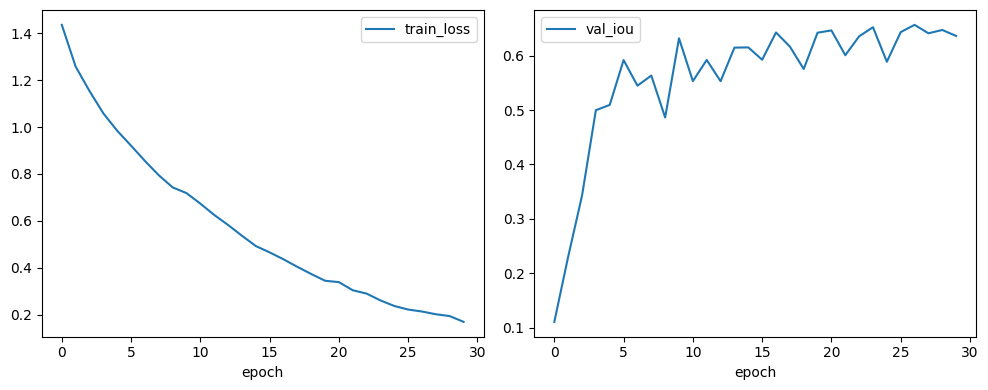

In [ ]:
import matplotlib.pyplot as plt
if len(train_losses)>0:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='train_loss')
    plt.xlabel('epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(val_ious, label='val_iou')
    plt.xlabel('epoch'); plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training history yet.")


In [ ]:
# Load best model if exists
if os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    print("Best model loaded for inference.")
else:
    print("Best model not found. Using current model (may be last checkpoint).")


Best model loaded for inference.


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def predict_overlay(img_path, threshold=0.5):
    img = cv2.imread(img_path)[:,:,::-1]
    h,w = img.shape[:2]
    inp = val_tf(image=img)["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = torch.sigmoid(model(inp))[0,0].cpu().numpy()
    mask = (pred > threshold).astype('uint8')
    mask = cv2.resize(mask, (w,h))
    overlay = img.copy()
    # colorize overlay (red) with alpha blend
    color = np.array([255,0,0], dtype=np.uint8)
    alpha = 0.5
    overlay[mask==1] = (overlay[mask==1] * (1-alpha) + color * alpha).astype(np.uint8)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1); plt.title("Original"); plt.imshow(img); plt.axis('off')
    plt.subplot(1,2,2); plt.title("Overlay"); plt.imshow(overlay); plt.axis('off')
    plt.show()

# Example usage:
# predict_overlay(os.path.join(IMAGES_DIR, sorted(os.listdir(IMAGES_DIR))[0]))


In [ ]:
OUT_PRED_DIR = os.path.join("/content/drive/MyDrive", "pred_masks")
os.makedirs(OUT_PRED_DIR, exist_ok=True)

model.eval()
with torch.no_grad():
    for fname in sorted(os.listdir(IMAGES_DIR)):
        if not fname.lower().endswith(('.jpg','.png','.jpeg')): continue
        img_path = os.path.join(IMAGES_DIR, fname)
        img = cv2.imread(img_path)[:,:,::-1]
        inp = val_tf(image=img)["image"].unsqueeze(0).to(DEVICE)
        pred = torch.sigmoid(model(inp))[0,0].cpu().numpy()
        mask = (pred > 0.5).astype('uint8') * 255
        # resize back to original image size
        h,w = img.shape[:2]
        mask = cv2.resize(mask, (w,h))
        save_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")
        cv2.imwrite(save_path, mask)
print("Saved predictions to:", OUT_PRED_DIR)


Saved predictions to: /content/drive/MyDrive/pred_masks


Showing: Salinan ringworm-54-_jpg.rf.83d30666af97e54cddab375545b60fd3.jpg


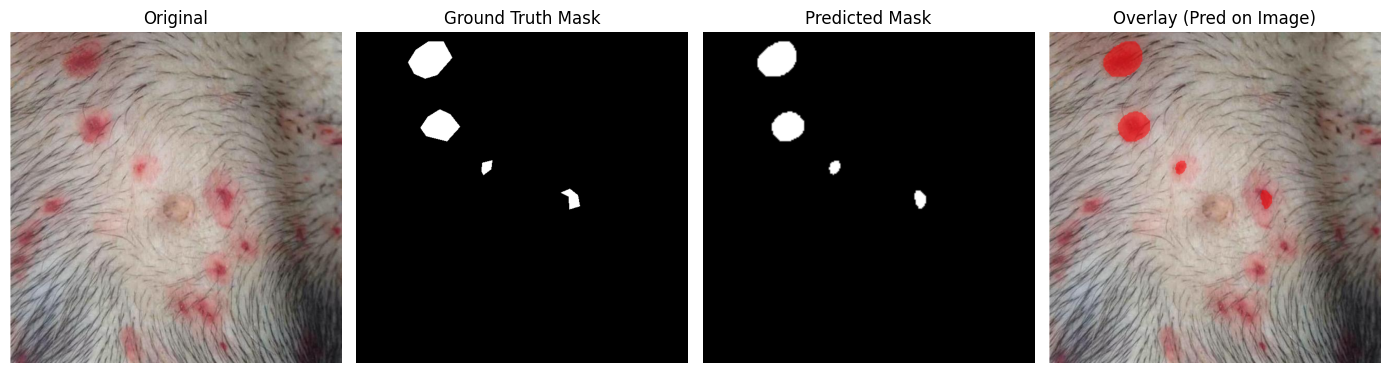

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random
import torch

def show_prediction(fname):
    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, os.path.splitext(fname)[0] + ".png")
    pred_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")

    # --- Load original ---
    img = cv2.imread(img_path)[:,:,::-1]

    # --- Load ground truth ---
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        gt = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Load predicted mask ---
    pred = cv2.imread(pred_path, 0)
    if pred is None:
        pred = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Make overlay from predicted mask ---
    overlay = img.copy()
    color = np.array([255, 0, 0])   # red overlay
    alpha = 0.5

    overlay[pred > 127] = (overlay[pred > 127] * (1-alpha) + color * alpha).astype(np.uint8)

    # --- Plot all ---
    plt.figure(figsize=(14,7))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth Mask")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Pred on Image)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run this to show one sample ---
sample = random.choice(sorted(os.listdir(IMAGES_DIR)))
print("Showing:", sample)
show_prediction(sample)


Showing: Salinan 438051747_429300536462648_7834621964132658771_n_jpg.rf.0db245ea8a8749a12a3f124c68dfe865.jpg


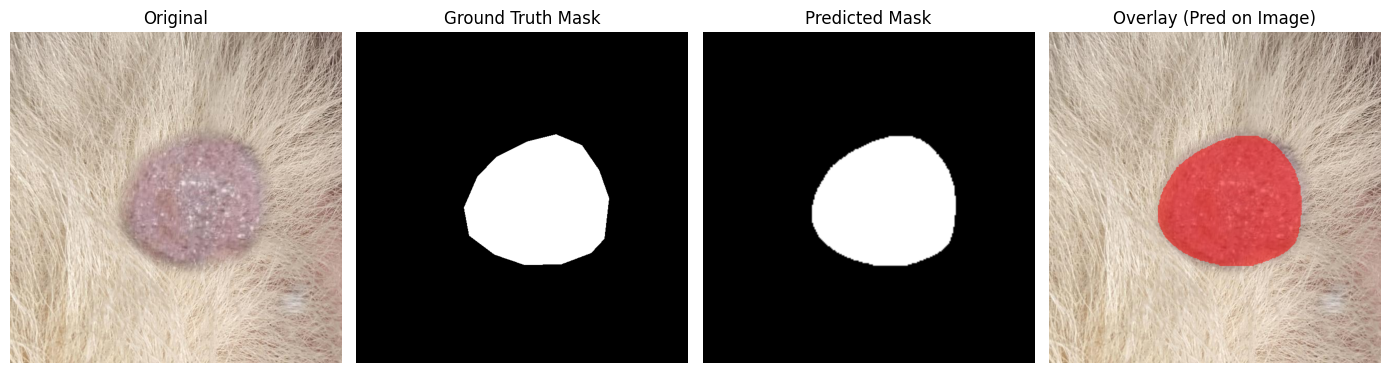

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random
import torch

def show_prediction(fname):
    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, os.path.splitext(fname)[0] + ".png")
    pred_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")

    # --- Load original ---
    img = cv2.imread(img_path)[:,:,::-1]

    # --- Load ground truth ---
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        gt = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Load predicted mask ---
    pred = cv2.imread(pred_path, 0)
    if pred is None:
        pred = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Make overlay from predicted mask ---
    overlay = img.copy()
    color = np.array([255, 0, 0])   # red overlay
    alpha = 0.5

    overlay[pred > 127] = (overlay[pred > 127] * (1-alpha) + color * alpha).astype(np.uint8)

    # --- Plot all ---
    plt.figure(figsize=(14,7))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth Mask")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Pred on Image)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run this to show one sample ---
sample = random.choice(sorted(os.listdir(IMAGES_DIR)))
print("Showing:", sample)
show_prediction(sample)


Showing: Salinan 1000010719_x16_jpg.rf.58e2c60ac35f45c420e2912052c73872.jpg


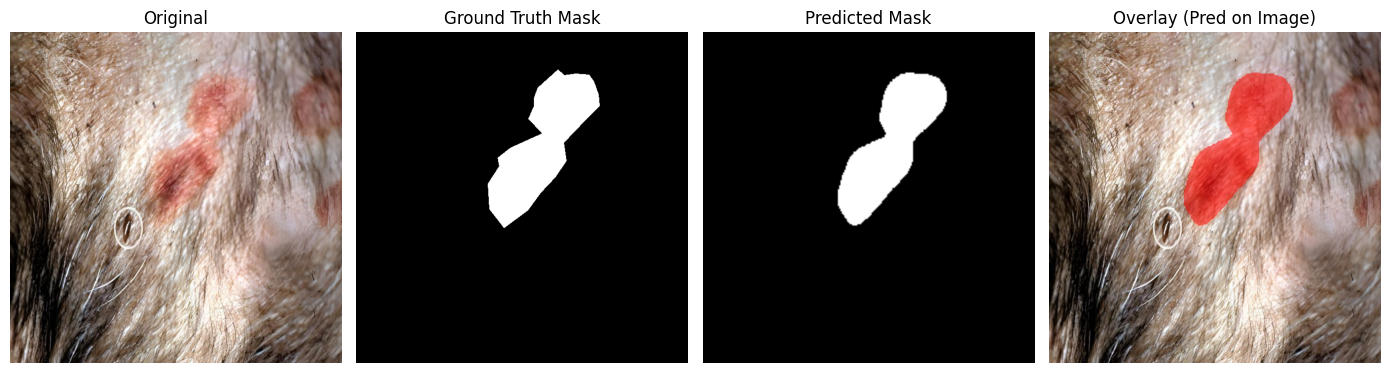

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random
import torch

def show_prediction(fname):
    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, os.path.splitext(fname)[0] + ".png")
    pred_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")

    # --- Load original ---
    img = cv2.imread(img_path)[:,:,::-1]

    # --- Load ground truth ---
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        gt = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Load predicted mask ---
    pred = cv2.imread(pred_path, 0)
    if pred is None:
        pred = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Make overlay from predicted mask ---
    overlay = img.copy()
    color = np.array([255, 0, 0])   # red overlay
    alpha = 0.5

    overlay[pred > 127] = (overlay[pred > 127] * (1-alpha) + color * alpha).astype(np.uint8)

    # --- Plot all ---
    plt.figure(figsize=(14,7))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth Mask")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Pred on Image)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run this to show one sample ---
sample = random.choice(sorted(os.listdir(IMAGES_DIR)))
print("Showing:", sample)
show_prediction(sample)


Showing: Salinan ringworm-52-_jpg.rf.b89bd14a699d99bc8e1028a96c9d9772.jpg


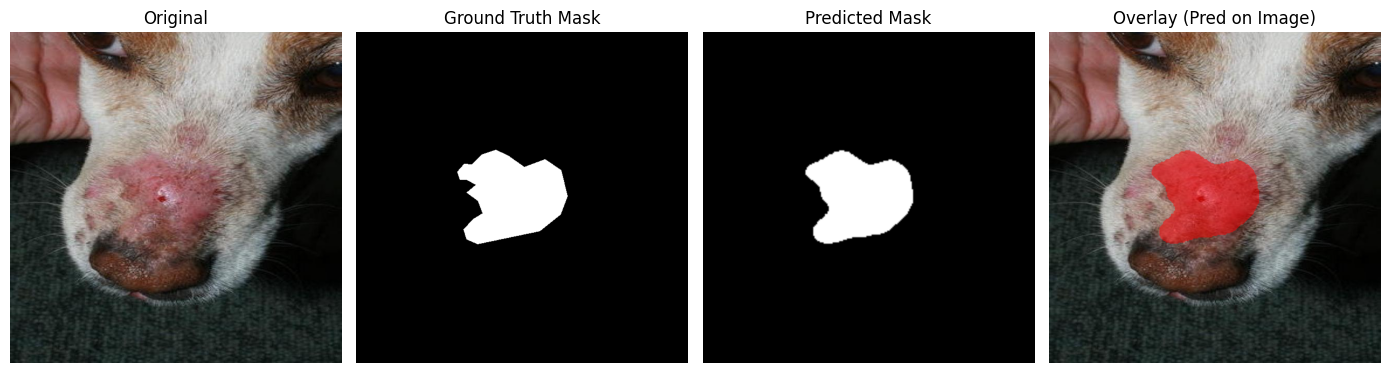

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random
import torch

def show_prediction(fname):
    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, os.path.splitext(fname)[0] + ".png")
    pred_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")

    # --- Load original ---
    img = cv2.imread(img_path)[:,:,::-1]

    # --- Load ground truth ---
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        gt = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Load predicted mask ---
    pred = cv2.imread(pred_path, 0)
    if pred is None:
        pred = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Make overlay from predicted mask ---
    overlay = img.copy()
    color = np.array([255, 0, 0])   # red overlay
    alpha = 0.5

    overlay[pred > 127] = (overlay[pred > 127] * (1-alpha) + color * alpha).astype(np.uint8)

    # --- Plot all ---
    plt.figure(figsize=(14,7))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth Mask")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Pred on Image)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run this to show one sample ---
sample = random.choice(sorted(os.listdir(IMAGES_DIR)))
print("Showing:", sample)
show_prediction(sample)


Showing: Salinan 436886639_984826669663928_3052914574866382434_n_jpg.rf.ad6156c5fd3ef28cbe8366b974e32dae.jpg


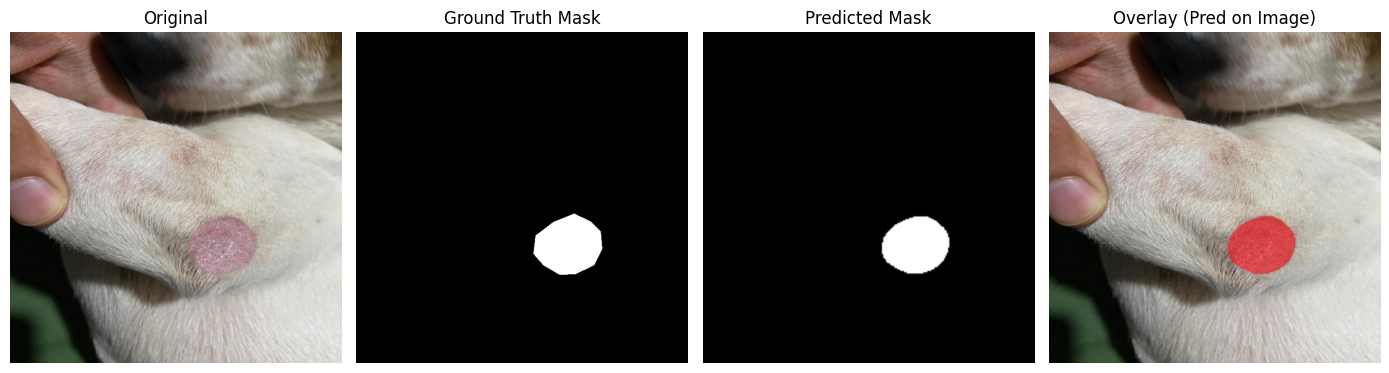

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random
import torch

def show_prediction(fname):
    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, os.path.splitext(fname)[0] + ".png")
    pred_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")

    # --- Load original ---
    img = cv2.imread(img_path)[:,:,::-1]

    # --- Load ground truth ---
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        gt = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Load predicted mask ---
    pred = cv2.imread(pred_path, 0)
    if pred is None:
        pred = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Make overlay from predicted mask ---
    overlay = img.copy()
    color = np.array([255, 0, 0])   # red overlay
    alpha = 0.5

    overlay[pred > 127] = (overlay[pred > 127] * (1-alpha) + color * alpha).astype(np.uint8)

    # --- Plot all ---
    plt.figure(figsize=(14,7))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth Mask")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Pred on Image)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run this to show one sample ---
sample = random.choice(sorted(os.listdir(IMAGES_DIR)))
print("Showing:", sample)
show_prediction(sample)


Showing: Salinan NEWR47_png_jpg.rf.5dddad8b6fb9cd516d1e5ffeb6d193ed.jpg


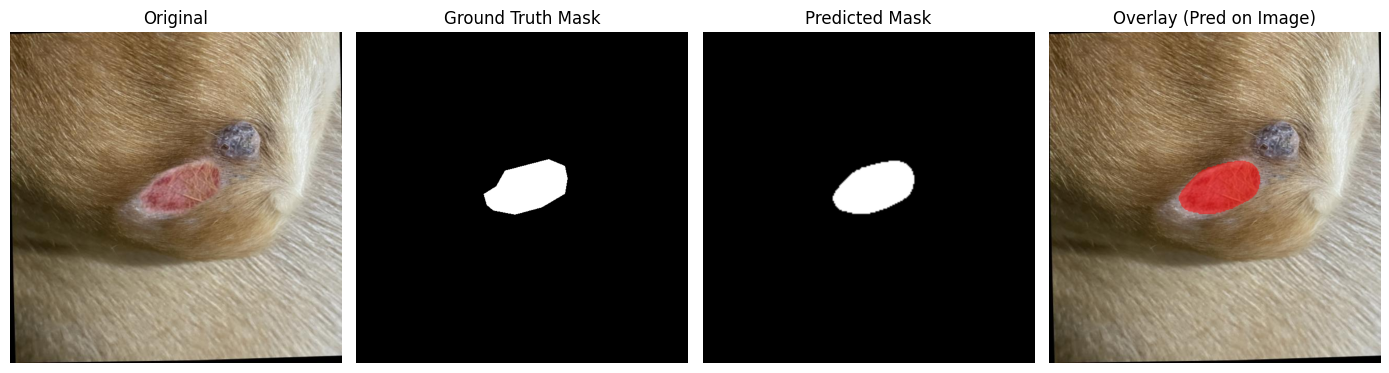

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random
import torch

def show_prediction(fname):
    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, os.path.splitext(fname)[0] + ".png")
    pred_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")

    # --- Load original ---
    img = cv2.imread(img_path)[:,:,::-1]

    # --- Load ground truth ---
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        gt = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Load predicted mask ---
    pred = cv2.imread(pred_path, 0)
    if pred is None:
        pred = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Make overlay from predicted mask ---
    overlay = img.copy()
    color = np.array([255, 0, 0])   # red overlay
    alpha = 0.5

    overlay[pred > 127] = (overlay[pred > 127] * (1-alpha) + color * alpha).astype(np.uint8)

    # --- Plot all ---
    plt.figure(figsize=(14,7))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth Mask")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Pred on Image)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run this to show one sample ---
sample = random.choice(sorted(os.listdir(IMAGES_DIR)))
print("Showing:", sample)
show_prediction(sample)


Showing: Salinan R22_png_jpg.rf.352645f72cbd72fbb1fa5368b637ada3.jpg


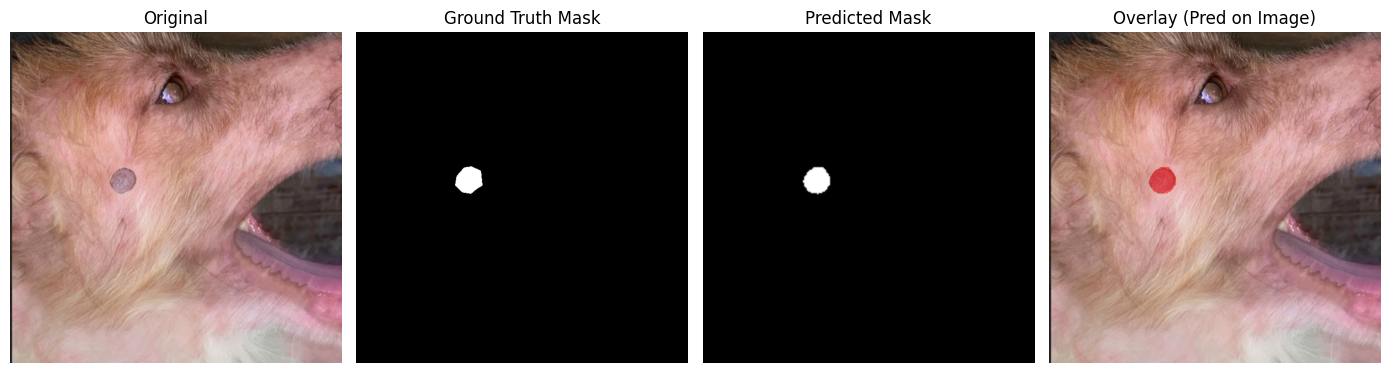

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random
import torch

def show_prediction(fname):
    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, os.path.splitext(fname)[0] + ".png")
    pred_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")

    # --- Load original ---
    img = cv2.imread(img_path)[:,:,::-1]

    # --- Load ground truth ---
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        gt = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Load predicted mask ---
    pred = cv2.imread(pred_path, 0)
    if pred is None:
        pred = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Make overlay from predicted mask ---
    overlay = img.copy()
    color = np.array([255, 0, 0])   # red overlay
    alpha = 0.5

    overlay[pred > 127] = (overlay[pred > 127] * (1-alpha) + color * alpha).astype(np.uint8)

    # --- Plot all ---
    plt.figure(figsize=(14,7))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth Mask")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Pred on Image)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run this to show one sample ---
sample = random.choice(sorted(os.listdir(IMAGES_DIR)))
print("Showing:", sample)
show_prediction(sample)


Showing: Salinan ringworm-109-_jpg.rf.7e5b73d3e7c6e3bde3ab5615e15a5757.jpg


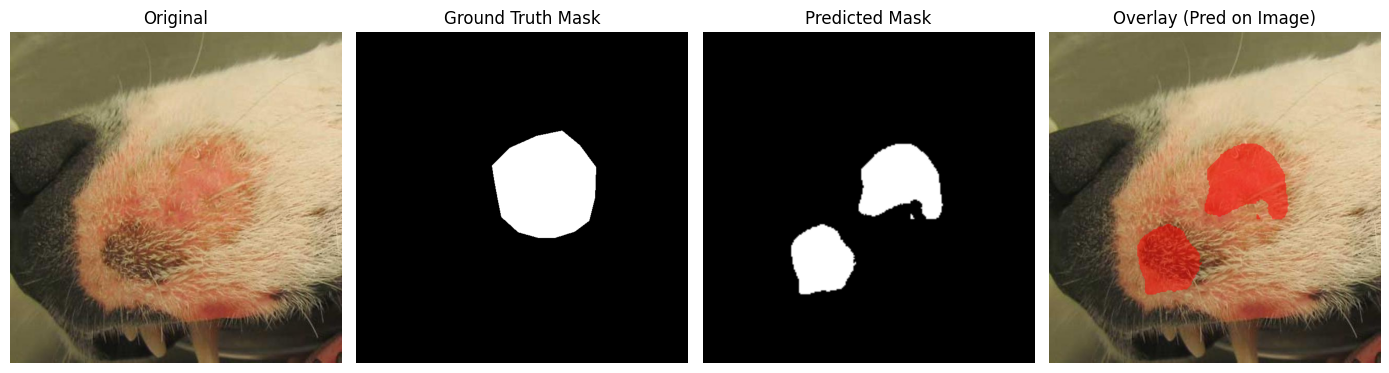

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random
import torch

def show_prediction(fname):
    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, os.path.splitext(fname)[0] + ".png")
    pred_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")

    # --- Load original ---
    img = cv2.imread(img_path)[:,:,::-1]

    # --- Load ground truth ---
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        gt = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Load predicted mask ---
    pred = cv2.imread(pred_path, 0)
    if pred is None:
        pred = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Make overlay from predicted mask ---
    overlay = img.copy()
    color = np.array([255, 0, 0])   # red overlay
    alpha = 0.5

    overlay[pred > 127] = (overlay[pred > 127] * (1-alpha) + color * alpha).astype(np.uint8)

    # --- Plot all ---
    plt.figure(figsize=(14,7))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth Mask")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Pred on Image)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run this to show one sample ---
sample = random.choice(sorted(os.listdir(IMAGES_DIR)))
print("Showing:", sample)
show_prediction(sample)


Showing: Salinan ringworm-74-_jpg.rf.1c15a9cc9f380ceaa590173c53603c5b.jpg


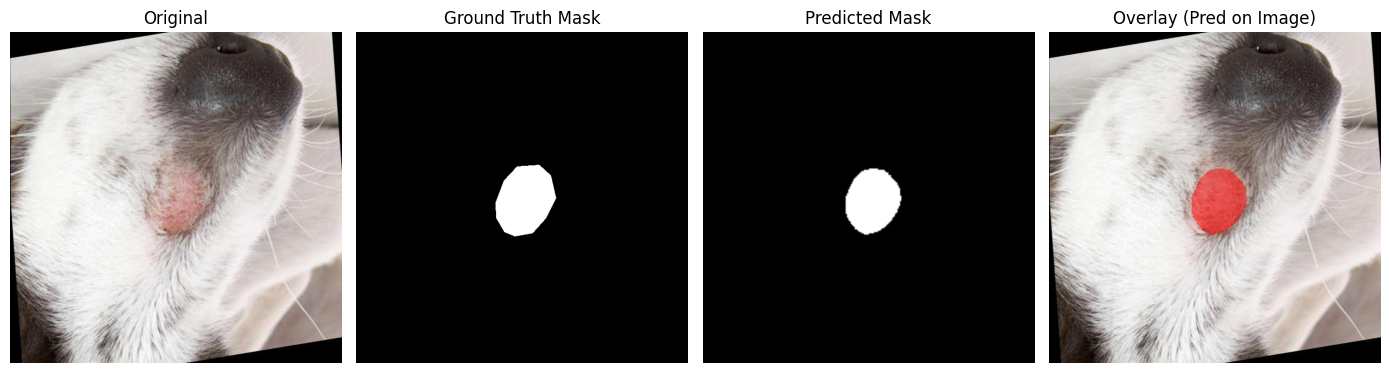

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random
import torch

def show_prediction(fname):
    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, os.path.splitext(fname)[0] + ".png")
    pred_path = os.path.join(OUT_PRED_DIR, os.path.splitext(fname)[0] + ".png")

    # --- Load original ---
    img = cv2.imread(img_path)[:,:,::-1]

    # --- Load ground truth ---
    gt = cv2.imread(mask_path, 0)
    if gt is None:
        gt = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Load predicted mask ---
    pred = cv2.imread(pred_path, 0)
    if pred is None:
        pred = np.zeros(img.shape[:2], dtype=np.uint8)

    # --- Make overlay from predicted mask ---
    overlay = img.copy()
    color = np.array([255, 0, 0])   # red overlay
    alpha = 0.5

    overlay[pred > 127] = (overlay[pred > 127] * (1-alpha) + color * alpha).astype(np.uint8)

    # --- Plot all ---
    plt.figure(figsize=(14,7))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Ground Truth Mask")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Overlay (Pred on Image)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# --- Run this to show one sample ---
sample = random.choice(sorted(os.listdir(IMAGES_DIR)))
print("Showing:", sample)
show_prediction(sample)
